## Notebook Overview 

In this notebook we will be making a Image Classification model  traind on MNIST digit dataset using keras 3 API.

We will train this model and save it using 2 formats(".h5" and ".keras") , for converting it to coreml package.

Once the conversion is completed we will load the mlpackage and make predictions to verify the conversion process was successful 

## Checking the version 

In [7]:
import tensorflow as tf 
import numpy as np
import coremltools as ct
import warnings
import os 
import PIL
from PIL import Image
import matplotlib
import types
import time 
import pathlib
import collections
from collections import Counter
import matplotlib.pyplot as plt      
warnings.filterwarnings("ignore")

print("Tensorflow Version : ",tf.__version__)
print("Keras Version : ",tf.keras.__version__)
print("Numpy Version : ",np.__version__)
print("CoreMLTools Version : ",ct.__version__)
print("PIL Version : ",PIL.__version__)
print("Matplotlib Version : ",matplotlib.__version__)

Tensorflow Version :  2.19.0
Keras Version :  3.9.2
Numpy Version :  2.1.3
CoreMLTools Version :  8.2
PIL Version :  11.2.1
Matplotlib Version :  3.10.1


## Downloading the dataset and Training the model 

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
x_train = x_train[..., tf.newaxis]   
x_test  = x_test[...,  tf.newaxis]   

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax"),  # 10 digit classes
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()
model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7787 - loss: 0.7032 - val_accuracy: 0.9825 - val_loss: 0.0671
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9656 - loss: 0.1175 - val_accuracy: 0.9873 - val_loss: 0.0424
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9757 - loss: 0.0804 - val_accuracy: 0.9893 - val_loss: 0.0380
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9803 - loss: 0.0660 - val_accuracy: 0.9895 - val_loss: 0.0348
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9858 - loss: 0.0509 - val_accuracy: 0.9920 - val_loss: 0.0302
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9858 - loss: 0.0479 - val_accuracy: 0.9910 - val_loss: 0.0324
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9871 - loss: 0.0430 - val_accuracy: 0.9915 - val_loss: 0.0350
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9885 - loss: 0.0366 - val_accu

## Saving the model 

In [3]:
path = "./saved_model"
name_h5 = "mnist.h5"
name_keras = "mnist.keras"

fpath_h5 = os.path.join(path,name_h5)
fpath_keras = os.path.join(path,name_keras)


model.save(fpath_h5)
model.save(fpath_keras)


## Loading the model 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


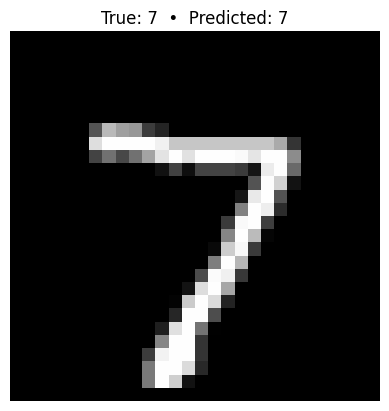

In [4]:
loaded_model_keras = tf.keras.models.load_model(fpath_keras)

(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_test = x_test.astype("float32") / 255.0
x_test = x_test[..., tf.newaxis]

pred_prob  = model.predict(x_test[:1])
pred_label = int(np.argmax(pred_prob, axis=-1)[0])

plt.imshow(x_test[0].squeeze(), cmap="gray")
plt.title(f"True: {y_test[0]}  •  Predicted: {pred_label}")
plt.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


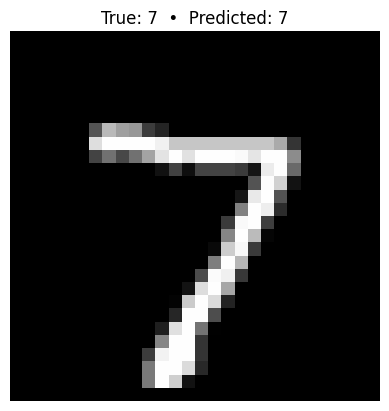

In [5]:
loaded_model_h5 = tf.keras.models.load_model(fpath_h5)

(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_test = x_test.astype("float32") / 255.0
x_test = x_test[..., tf.newaxis]

pred_prob  = model.predict(x_test[:1])
pred_label = int(np.argmax(pred_prob, axis=-1)[0])

plt.imshow(x_test[0].squeeze(), cmap="gray")
plt.title(f"True: {y_test[0]}  •  Predicted: {pred_label}")
plt.axis("off")
plt.show()


## Converting the saved model using coremltools


In [13]:
coremlmodel = ct.convert(
    loaded_model_keras,
    source="tensorflow",
    inputs=[ct.TensorType(name="input_layer", shape=(1,28,28,1), dtype=np.float32)],
    minimum_deployment_target=ct.target.macOS13,
    convert_to="mlprogram"
)

AttributeError: 'Sequential' object has no attribute '_get_save_spec'

## Trying the fix mention in the follwoing Comment

[Reference: Github Issue comment 2224947498](https://github.com/tensorflow/tensorflow/issues/71726#issuecomment-2224947498)

In [ ]:
import os

os.environ["TF_USE_LEGACY_KERAS"]="1"

loaded_model_keras = tf.keras.models.load_model(fpath_keras)
coremlmodel = ct.convert(
    loaded_model_keras,
    source="tensorflow",
    inputs=[ct.TensorType(name="input_layer", shape=(1,28,28,1), dtype=np.float32)],
    minimum_deployment_target=ct.target.macOS13,
    convert_to="mlprogram"
)

# CoreMLTools Compatibility Issue with TensorFlow/Keras 2.16+

## Problem
`coremltools` needs to trace the model to build a Core ML graph. It calls TensorFlow's private helper `saving_utils.model_input_signature()` → which in turn calls `model._get_save_spec()` to obtain an input signature.  
[Reference: TensorFlow Issue #39001](https://github.com/tensorflow/tensorflow/issues/39001)

## Some background
- Up through TensorFlow 2.15 / tf-keras 2.x, every `tf.keras.Model` (including Sequential) implemented `_get_save_spec`
- Starting in Keras 3 / TF 2.16+, the method was removed or renamed as part of the big "keras-core split"  
[Reference: TensorFlow Issue #63867](https://github.com/tensorflow/tensorflow/issues/63867)  
[Reference: Error when converting model to CoreML #60703](https://github.com/tensorflow/tensorflow/issues/60703)

## Why it crashes >?
Because coremltools 8.x still assumes the old API, it tries to call the attribute which is missing now and crashes with the follwoing error:

[Reference: StackOverflow Discussion](https://stackoverflow.com/questions/78839640/attributeerror-sequential-object-has-no-attribute-get-save-spec)

In [ ]:
def _patch_save_spec(model):
    def _get_save_spec(self, *args, **kwargs):
        dyn_batch = kwargs.get("dynamic_batch", True)
        specs = []
        
        for t in self.inputs:
            shape = list(t.shape)
            if dyn_batch:
                shape[0] = None
                
            specs.append(tf.TensorSpec(
                shape=tuple(shape),
                dtype=t.dtype,
                name=t.name.split(":")[0] 
            ))
            print("\nDefined Specs : ",specs)
        return specs
    
    model._get_save_spec = types.MethodType(_get_save_spec, model)
    
    
    if not hasattr(model, 'output_names'):
        model.output_names = [output.name.split(':')[0] for output in model.outputs]
        print("\nOutput_names : ",model.output_names)
    
    return model

keras_path = pathlib.Path("./saved_model/mnist.keras")
model      = tf.keras.models.load_model(keras_path)
print("loaded Keras model")

_patch_save_spec(model)

input_name  = model.inputs[0].name.split(":")[0]     
fixed_shape = (1, 28, 28, 1)                          


mlmodel = ct.convert(
    model,
    source="tensorflow",
    inputs=[ct.TensorType(name=input_name, shape=fixed_shape, dtype=np.float32)],
    minimum_deployment_target=ct.target.macOS13,      
    convert_to="mlprogram"
)                                                     
mlpkg_path = pathlib.Path("./saved_model/mnist_cnn.mlpackage")
mlmodel.save(mlpkg_path)
print(f"Core ML package saved to -> {mlpkg_path}")


✔ Loaded Keras model
Output_names :  ['keras_tensor_116']
Defined Specs :  [TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer')]


I0000 00:00:1745936292.784855   98234 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1745936292.785426   98234 single_machine.cc:374] Starting new session
I0000 00:00:1745936292.857334   98234 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1745936292.857407   98234 single_machine.cc:374] Starting new session
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 2075.79 passes/s]


✔ Core ML package saved → saved_model/mnist_cnn.mlpackage


## Why the _patch_save_spec works ? 

- The _patch_save_spec builds a list of tf.TensorSpec objects that describe each input from the saved model. 
- Setting shape[0] = None keeps the batch dimension flexible when dynamic_batch=True (the default) 
[Ref Links (Yet to add)]()

- Attach the method using the  types.MethodType	which monkey-patches the model class so coremltools finds the missing symbol when it calls model._get_save_spec() 
[Ref Links (Yet to add)]()

- Populates the model.output_names, Older coremltools versions falls back to this attribute when they can’t infer output names from the TF graph 
[Ref Links (Yet to add)]()



Input Names :  input_layer
\Spec Names :  specificationVersion: 7
description {
  input {
    name: "input_layer"
    type {
      multiArrayType {
        shape: 1
        shape: 28
        shape: 28
        shape: 1
        dataType: FLOAT32
      }
    }
  }
  output {
    name: "Identity"
    type {
      multiArrayType {
        shape: 1
        shape: 10
        dataType: FLOAT16
      }
    }
  }
  metadata {
    userDefined {
      key: "com.github.apple.coremltools.source"
      value: "tensorflow==2.19.0"
    }
    userDefined {
      key: "com.github.apple.coremltools.version"
      value: "8.2"
    }
  }
}
mlProgram {
  version: 1
  functions {
    key: "main"
    value {
      inputs {
        name: "input_layer"
        type {
          tensorType {
            dataType: FLOAT32
            rank: 4
            dimensions {
              constant {
                size: 1
              }
            }
            dimensions {
              constant {
                size:

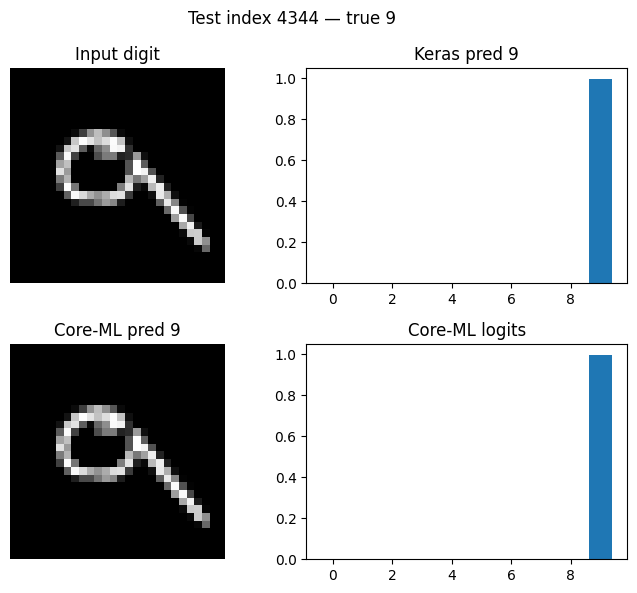

In [16]:
kerasmodel = tf.keras.models.load_model("./saved_model/mnist.keras")
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_test = (x_test.astype("float32") / 255.0)[..., np.newaxis]   

coremlmodel    = ct.models.MLModel("saved_model/mnist_cnn.mlpackage") 
input_name = kerasmodel.inputs[0].name.split(":")[0]
print("\nInput Names : ",input_name)
def _patch_rank3(model, inp):
    base_predict = model.predict
    def patched(data, *a, **kw):
        arr = data.get(inp)
        if isinstance(arr, np.ndarray) and arr.ndim == 3:       # (H,W,C)
            data = data.copy()
            data[inp] = arr[np.newaxis, ...]                   # → (1,H,W,C)
        return base_predict(data, *a, **kw)
    model.predict = patched
    return model

coremlmodel = _patch_rank3(coremlmodel, input_name)


spec    = coremlmodel.get_spec()
print("\Spec Names : ",spec)
is_clf  = bool(spec.description.predictedFeatureName)
out_key = spec.description.output[0].name  

def coreml_digit(img):
    out = coremlmodel.predict({input_name: img})
    if is_clf:
        return int(out["classLabel"])                     
    scores = out[out_key]                                
    return int(np.argmax(scores))                        

from matplotlib.ticker import MaxNLocator

def show_prediction_subplots(idx: int):

    img  = x_test[idx]
    true = int(y_test[idx])

    #Keras inference
    k_logits = kerasmodel.predict(img[np.newaxis, ...], verbose=0)[0]      
    k_pred   = int(np.argmax(k_logits))                                 

    #Core-ML inference 
    out_dict = coremlmodel.predict({input_name: img})
    if is_clf:
        cm_probs = np.array([out_dict["probabilities"][str(c)] for c in range(10)])
        cm_pred  = int(out_dict["classLabel"])
    else:                                                              
        cm_probs = out_dict[out_key].flatten()
        cm_pred  = int(np.argmax(cm_probs))                            

    # subplots
    fig, axs = plt.subplots(2, 2, figsize=(7, 6))                      
    fig.suptitle(f"Test index {idx} — true {true}")

    # (0,0) original image
    axs[0, 0].imshow(img.squeeze(), cmap="gray")                         
    axs[0, 0].set_title("Input digit")
    axs[0, 0].axis("off")

    axs[0, 1].bar(range(10), k_logits)
    axs[0, 1].set_title(f"Keras pred { k_pred }")
    axs[0, 1].xaxis.set_major_locator(MaxNLocator(integer=True))

    axs[1, 0].imshow(img.squeeze(), cmap="gray")
    axs[1, 0].set_title(f"Core-ML pred { cm_pred }")
    axs[1, 0].axis("off")

    axs[1, 1].bar(range(10), cm_probs)
    axs[1, 1].set_title("Core-ML probabilities" if is_clf else "Core-ML logits")
    axs[1, 1].xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()



t0 = time.perf_counter()
coreml_preds = [coreml_digit(im) for im in x_test]
coreml_time  = time.perf_counter() - t0

t1 = time.perf_counter()
keras_preds  = np.argmax(kerasmodel.predict(x_test, verbose=0), axis=-1)
keras_time   = time.perf_counter() - t1

acc = lambda y, p: (np.array(y) == np.array(p)).mean()
print(f"Keras   accuracy: {acc(y_test, keras_preds):.4f}  ({keras_time:.2f}s)")
print(f"Core-ML accuracy: {acc(y_test, coreml_preds):.4f}  ({coreml_time:.2f}s)")


show_prediction_subplots(4344)
